# Retail Sales Forecasting and Business Performance Analysis

## Business Problem

Retail businesses need accurate sales forecasting to optimize inventory management, workforce planning, and operational efficiency. Understanding historical sales patterns and key influencing factors can help organizations make better business decisions.

## Project Objective

The objective of this project is to analyze retail sales data, identify sales trends, evaluate factors affecting sales performance, and develop a Machine Learning model to forecast future weekly sales.

## Dataset Information

This project uses three datasets:

- Sales Data: Weekly sales records across multiple stores and departments.
- Features Data: Economic and environmental factors such as temperature, fuel price, CPI, unemployment, and holiday indicators.
- Stores Data: Store-specific information including store type and store size.

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Jupyter Notebook

# 1. Data Understanding

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 1.1 Loading the Datasets

In [2]:
sales = pd.read_csv("sales.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

## 1.2 Dataset Dimensions

In [3]:
print("Sales Dataset Shape:", sales.shape)
print("Features Dataset Shape:", features.shape)
print("Stores Dataset Shape:", stores.shape)

Sales Dataset Shape: (156000, 5)
Features Dataset Shape: (7800, 14)
Stores Dataset Shape: (50, 4)


## 1.3 Preview of the Datasets

In [4]:
sales.head()

,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1


In [5]:
features.head()

,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


In [6]:
stores.head()

,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North


## 1.4 Dataset Structure and Data Types

In [7]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   date          156000 non-null  object 
 3   weekly_sales  156000 non-null  float64
 4   is_holiday    156000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 6.0+ MB


In [8]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store_id      7800 non-null   int64  
 1   date          7800 non-null   object 
 2   temperature   7800 non-null   float64
 3   fuel_price    7800 non-null   float64
 4   markdown_1    7800 non-null   float64
 5   markdown_2    7800 non-null   float64
 6   markdown_3    7800 non-null   float64
 7   markdown_4    7800 non-null   float64
 8   markdown_5    7800 non-null   float64
 9   cpi           7800 non-null   float64
 10  unemployment  7800 non-null   float64
 11  is_holiday    7800 non-null   int64  
 12  holiday_name  900 non-null    object 
 13  season        7800 non-null   object 
dtypes: float64(9), int64(2), object(3)
memory usage: 853.3+ KB


In [9]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    50 non-null     int64 
 1   store_type  50 non-null     object
 2   store_size  50 non-null     int64 
 3   region      50 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.7+ KB


## 1.5 Missing Value Analysis

In [10]:
sales.isnull().sum()

store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

In [11]:
features.isnull().sum()

store_id           0
date               0
temperature        0
fuel_price         0
markdown_1         0
markdown_2         0
markdown_3         0
markdown_4         0
markdown_5         0
cpi                0
unemployment       0
is_holiday         0
holiday_name    6900
season             0
dtype: int64

In [12]:
stores.isnull().sum()

store_id      0
store_type    0
store_size    0
region        0
dtype: int64

### Initial Observations

- The Sales dataset contains 156,000 transaction records with no missing values.
- The Features dataset contains external factors such as temperature, fuel price, CPI, unemployment, and holiday information.
- The Stores dataset contains store-level information including store type, store size, and region.
- No missing values were found in the Sales and Stores datasets.
- The holiday_name column contains missing values, which appear to represent non-holiday periods rather than data quality issues.

# 2. Data Cleaning and Preparation

## 2.1 Convert Date Columns

In [13]:
sales['date'] = pd.to_datetime(sales['date'])
features['date'] = pd.to_datetime(features['date'])

In [14]:
sales.dtypes

store_id                 int64
department               int64
date            datetime64[ns]
weekly_sales           float64
is_holiday               int64
dtype: object

2.2 Handle Missing Holiday Names

In [15]:
features['holiday_name'] = features['holiday_name'].fillna('No Holiday')

In [16]:
features.isnull().sum()

store_id        0
date            0
temperature     0
fuel_price      0
markdown_1      0
markdown_2      0
markdown_3      0
markdown_4      0
markdown_5      0
cpi             0
unemployment    0
is_holiday      0
holiday_name    0
season          0
dtype: int64

## 2.3 Create Master Dataset

In [17]:
df = pd.merge(
    sales,
    features,
    on=['store_id', 'date'],
    how='left'
)

df = pd.merge(
    df,
    stores,
    on='store_id',
    how='left'
)

In [18]:
df.shape

(156000, 20)

In [19]:
df.head()

,store_id,department,date,weekly_sales,is_holiday_x,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday_y,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North


In [20]:
df.columns

Index(['store_id', 'department', 'date', 'weekly_sales', 'is_holiday_x',
       'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3',
       'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday_y',
       'holiday_name', 'season', 'store_type', 'store_size', 'region'],
      dtype='object')

## 2.4 Post-Merge Cleanup

In [21]:
df = df.drop(columns=['is_holiday_y'])

df = df.rename(
    columns={'is_holiday_x':'is_holiday'}
)

In [22]:
df.columns

Index(['store_id', 'department', 'date', 'weekly_sales', 'is_holiday',
       'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3',
       'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'holiday_name',
       'season', 'store_type', 'store_size', 'region'],
      dtype='object')

# 3. Exploratory Data Analysis (EDA)

In [23]:
## 3.1 Summary Statistics

In [24]:
df.describe()

,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size
count,156000.000000,156000.0000,156000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000
mean,25.500000,10.5000,2023-06-27 11:59:59.999999744,56503.488802,0.115385,59.875755,3.986344,2831.840176,1708.091033,2295.922200,1982.042679,2561.790629,240.469559,6.485572,136626.440000
min,1.000000,1.0000,2022-01-01 00:00:00,819.660000,0.000000,20.020000,2.500000,0.180000,0.200000,1.010000,1.130000,0.140000,180.000000,3.000000,31639.000000
25%,13.000000,5.7500,2022-09-29 06:00:00,21255.962500,0.000000,39.942500,3.240000,1308.727500,787.155000,1095.917500,969.917500,1198.375000,211.027500,4.720000,91417.000000
50%,25.500000,10.5000,2023-06-27 12:00:00,43394.870000,0.000000,60.065000,3.970000,2652.495000,1612.570000,2174.595000,1862.980000,2417.900000,240.945000,6.490000,140736.500000
75%,38.000000,15.2500,2024-03-24 18:00:00,79604.107500,0.000000,79.910000,4.750000,4027.545000,2423.002500,3212.695000,2790.137500,3600.245000,270.445000,8.220000,179797.000000
max,50.000000,20.0000,2024-12-21 00:00:00,505958.730000,1.000000,99.970000,5.500000,10977.070000,6599.720000,8798.150000,7692.880000,9891.190000,299.990000,10.000000,218696.000000
std,14.430916,5.7663,NaN,46717.490663,0.319487,23.114765,0.864025,1977.833293,1187.621364,1579.278801,1351.446660,1769.691198,34.600848,2.014998,53081.473652


## 3.2 Total Sales Revenue

In [25]:
total_sales = df['weekly_sales'].sum()

print(f"Total Revenue: ${total_sales:,.2f}")

Total Revenue: $8,814,544,253.11


## 3.3 Distribution of Weekly Sales

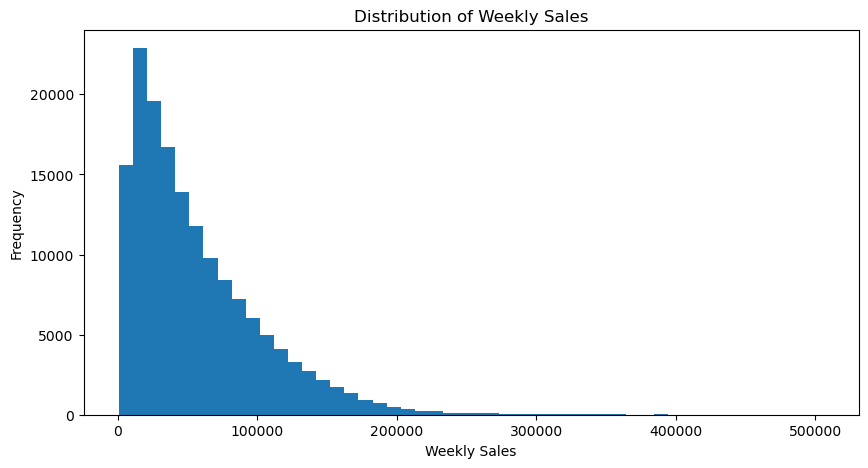

In [26]:
plt.figure(figsize=(10,5))

plt.hist(
    df['weekly_sales'],
    bins=50
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

## 3.4 Top Performing Stores

In [27]:
top_stores = (
    df.groupby('store_id')['weekly_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_stores

store_id
32    3.032230e+08
41    3.018119e+08
5     3.000639e+08
1     2.999050e+08
11    2.923540e+08
37    2.913743e+08
6     2.901179e+08
47    2.857667e+08
38    2.807494e+08
23    2.796390e+08
Name: weekly_sales, dtype: float64

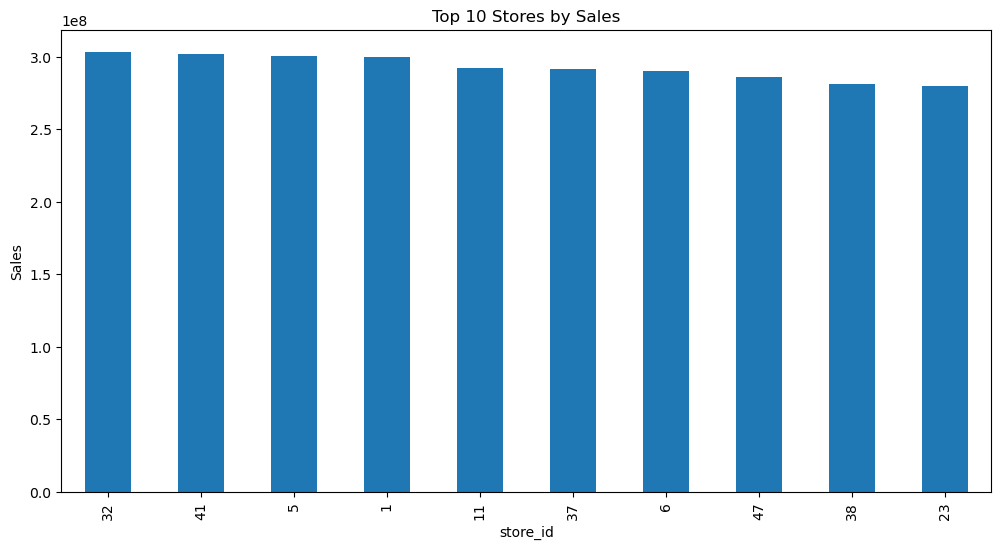

In [28]:
plt.figure(figsize=(12,6))

top_stores.plot(kind='bar')

plt.title("Top 10 Stores by Sales")
plt.ylabel("Sales")

plt.show()

### Business Insight

Store 32 generated the highest total sales revenue, followed closely by Stores 41 and 5.

The sales difference among the top-performing stores is relatively small, indicating strong and consistent performance across leading stores.

These stores can be analyzed further to identify operational practices that contribute to higher sales performance.

Top Performing Departments

In [29]:
top_departments = (
    df.groupby('department')['weekly_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_departments

department
20    5.923036e+08
19    5.725349e+08
18    5.601886e+08
17    5.398004e+08
16    5.296860e+08
15    5.089252e+08
14    4.917602e+08
13    4.749228e+08
12    4.671906e+08
11    4.541135e+08
Name: weekly_sales, dtype: float64

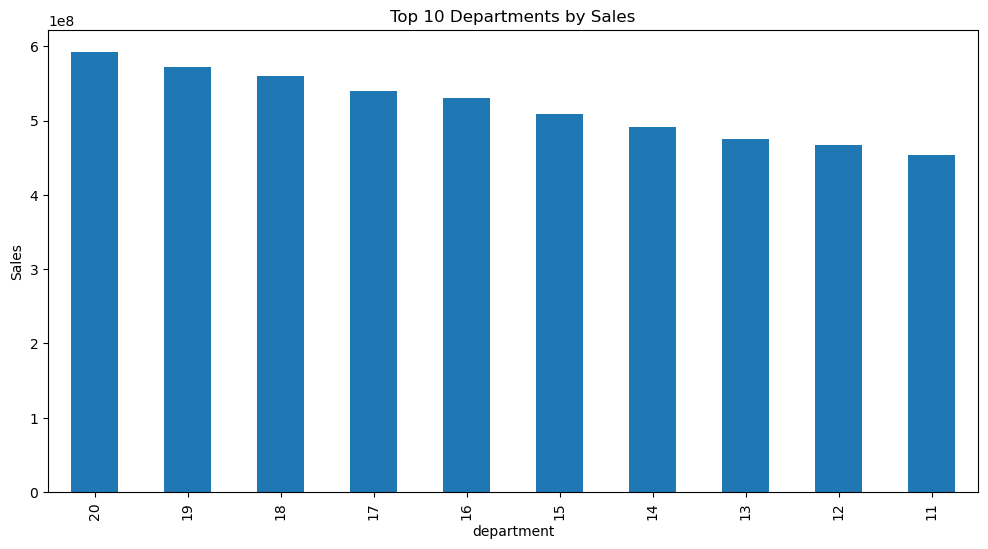

In [30]:
plt.figure(figsize=(12,6))

top_departments.plot(kind='bar')

plt.title("Top 10 Departments by Sales")
plt.ylabel("Sales")

plt.show()

### Business Insight

Department 20 generated the highest sales revenue, followed by Departments 19 and 18.

The results suggest that these departments contribute significantly to overall business performance and should receive priority in inventory planning and promotional activities.

# 4. Holiday and Seasonal Sales Analysis

In [31]:
holiday_sales = (
    df.groupby('is_holiday')['weekly_sales']
      .mean()
)

holiday_sales

is_holiday
0    52852.575328
1    84493.825439
Name: weekly_sales, dtype: float64

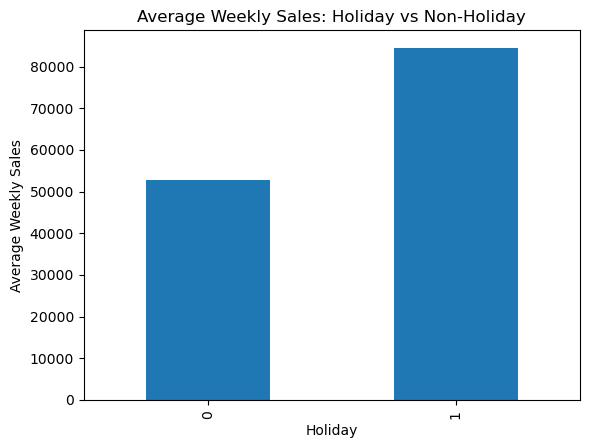

In [32]:
import matplotlib.pyplot as plt

holiday_sales.plot(kind='bar')

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")

plt.show()

Sales by Season

In [33]:
season_sales = (
    df.groupby('season')['weekly_sales']
      .mean()
      .sort_values(ascending=False)
)

season_sales

season
Fall      64705.829117
Winter    62372.869375
Summer    50143.842221
Spring    49104.979294
Name: weekly_sales, dtype: float64

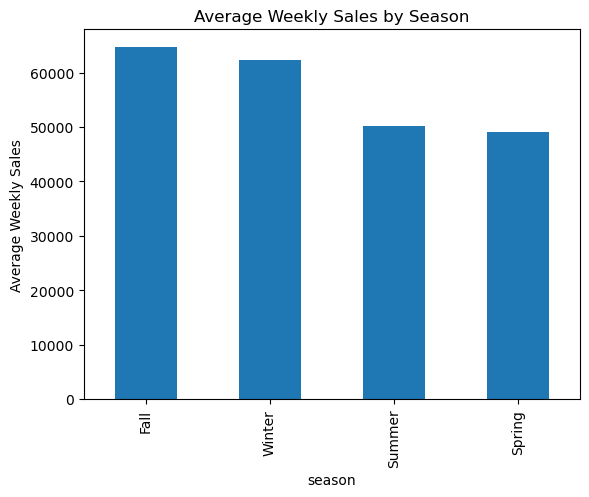

In [34]:
season_sales.plot(kind='bar')

plt.title("Average Weekly Sales by Season")
plt.ylabel("Average Weekly Sales")

plt.show()

Sales by Region

In [35]:
region_sales = (
    df.groupby('region')['weekly_sales']
      .mean()
      .sort_values(ascending=False)
)

region_sales

region
North    61200.892230
East     58083.349419
West     52568.973281
South    52259.040905
Name: weekly_sales, dtype: float64

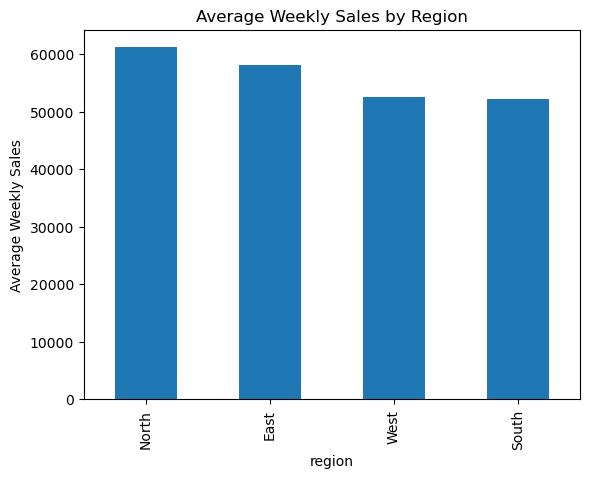

In [36]:
region_sales.plot(kind='bar')

plt.title("Average Weekly Sales by Region")
plt.ylabel("Average Weekly Sales")

plt.show()

5. Correlation Analysis

In [37]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

corr_matrix['weekly_sales'].sort_values(ascending=False)

weekly_sales    1.000000
store_size      0.585898
department      0.248255
is_holiday      0.216385
markdown_1      0.106318
markdown_2      0.105280
markdown_4      0.100456
markdown_5      0.100337
markdown_3      0.093338
store_id        0.016261
cpi            -0.001532
temperature    -0.001684
fuel_price     -0.002101
unemployment   -0.006974
Name: weekly_sales, dtype: float64

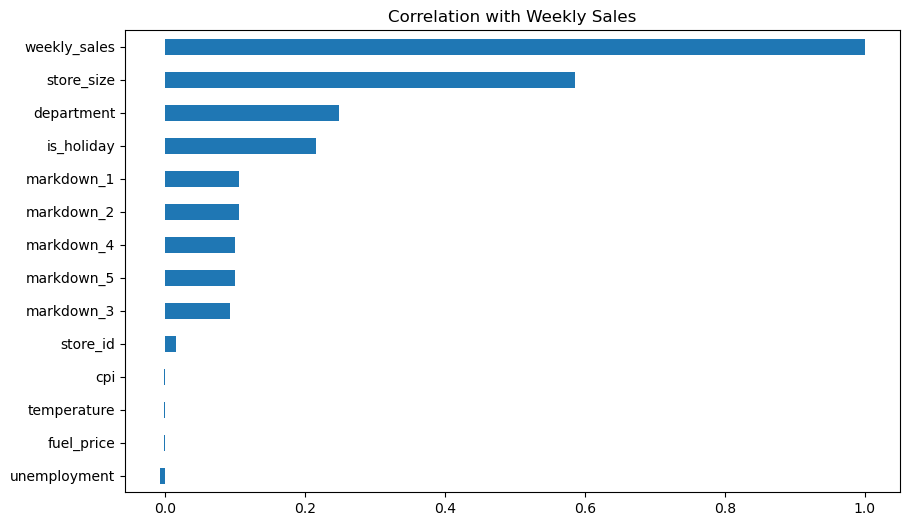

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

corr_matrix['weekly_sales'].sort_values().plot(kind='barh')

plt.title("Correlation with Weekly Sales")

plt.show()

# 6. Feature Engineering

In [39]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['dayofweek'] = df['date'].dt.dayofweek

In [40]:
df[['date','year','month','week','dayofweek']].head()

,date,year,month,week,dayofweek
0,2022-01-01,2022,1,52,5
1,2022-01-01,2022,1,52,5
2,2022-01-01,2022,1,52,5
3,2022-01-01,2022,1,52,5
4,2022-01-01,2022,1,52,5


# 7. Machine Learning Sales Forecasting

The objective of this section is to build predictive models that estimate future weekly sales using historical sales data, store information, seasonal factors, and economic indicators.

Two machine learning algorithms will be evaluated and compared based on predictive performance.

In [41]:
ml_df = df.copy()

ml_df.head()

,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,...,unemployment,holiday_name,season,store_type,store_size,region,year,month,week,dayofweek
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,New Year,Winter,A,213810,North,2022,1,52,5
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,New Year,Winter,A,213810,North,2022,1,52,5
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,New Year,Winter,A,213810,North,2022,1,52,5
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,New Year,Winter,A,213810,North,2022,1,52,5
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,New Year,Winter,A,213810,North,2022,1,52,5


Remove Unnecessary Columns

In [42]:
ml_df = ml_df.drop(
    columns=[
        'date',
        'holiday_name'
    ],
    errors='ignore'
)

ml_df.head()

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,...,cpi,unemployment,season,store_type,store_size,region,year,month,week,dayofweek
0,1,1,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,203.52,3.32,Winter,A,213810,North,2022,1,52,5
1,1,2,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,203.52,3.32,Winter,A,213810,North,2022,1,52,5
2,1,3,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,203.52,3.32,Winter,A,213810,North,2022,1,52,5
3,1,4,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,203.52,3.32,Winter,A,213810,North,2022,1,52,5
4,1,5,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,203.52,3.32,Winter,A,213810,North,2022,1,52,5


Convert Categorical Variables

In [43]:
ml_df = pd.get_dummies(
    ml_df,
    columns=[
        'store_type',
        'region',
        'season'
    ],
    drop_first=True
)

ml_df.head()

,store_id,department,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,...,week,dayofweek,store_type_B,store_type_C,region_North,region_South,region_West,season_Spring,season_Summer,season_Winter
0,1,1,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,52,5,False,False,True,False,False,False,False,True
1,1,2,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,52,5,False,False,True,False,False,False,False,True
2,1,3,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,52,5,False,False,True,False,False,False,False,True
3,1,4,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,52,5,False,False,True,False,False,False,False,True
4,1,5,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,...,52,5,False,False,True,False,False,False,False,True


Define Features and Target

In [44]:
X = ml_df.drop('weekly_sales', axis=1)

y = ml_df['weekly_sales']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (156000, 25)
Target Shape: (156000,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (124800, 25)
Test Shape: (31200, 25)


In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Model Trained Successfully!")

Model Trained Successfully!


Evaluate the Model

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error(
    y_test,
    lr_pred
) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Results
-------------------------
MAE : 25209.375833411978
RMSE: 33700.707357107116
R²  : 0.47243678521104404


## 7.2 Linear Regression Evaluation

The Linear Regression model achieved an R² score of 0.47, indicating that approximately 47% of the variance in weekly sales was explained by the selected features.

While the model captured general sales trends, the relatively high MAE and RMSE values suggest that more complex relationships may exist in the data. Therefore, an ensemble-based model was explored to improve prediction accuracy.

Train Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


evaluate it

In [49]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 25511.21347655769
RMSE: 35281.61627256174
R²  : 0.421779589913416


## 7.3 Model Comparison

Two machine learning models were evaluated for weekly sales forecasting.

| Model | MAE | RMSE | R² |
|--------|--------|--------|--------|
| Linear Regression | 25209 | 33701 | 0.472 |
| Random Forest | 25511 | 35282 | 0.422 |

The Linear Regression model achieved better performance across all evaluation metrics. It produced lower prediction errors and explained a higher proportion of variance in weekly sales.

Therefore, Linear Regression was selected as the final forecasting model for this project.

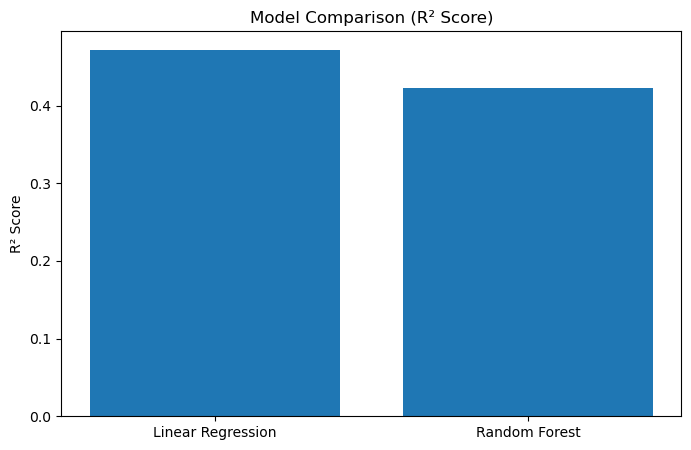

In [50]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [0.472, 0.422]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title('Model Comparison (R² Score)')
plt.ylabel('R² Score')

plt.show()

# 8. Conclusion

This project analyzed retail sales data from multiple stores and departments to understand sales behavior and develop a forecasting model.

Key findings include:

- Weekly sales exhibit significant variation across stores and departments.
- Department 20 generated the highest sales revenue.
- Stores 32 and 41 were among the top-performing locations.
- Holiday periods showed noticeable impacts on sales performance.
- Linear Regression achieved the best forecasting performance with an R² score of 0.47.

The results demonstrate that historical sales, store characteristics, and economic indicators can be used to predict future retail sales and support business decision-making.

# 9. Business Recommendations

Based on the analysis and forecasting results, the following recommendations are suggested:

- Focus inventory planning on high-performing departments such as Department 20 and Department 19.
- Allocate additional resources to top-performing stores to maximize revenue opportunities.
- Monitor holiday periods closely, as they significantly influence weekly sales patterns.
- Use forecasting models to improve inventory management and reduce stock shortages.
- Continuously collect external factors such as fuel prices, unemployment rates, and promotional markdowns to improve future forecasting accuracy.

# 10. Project Summary

This project developed an end-to-end retail sales forecasting solution using historical sales data, store information, and external economic factors.

The analysis identified key sales trends, top-performing stores and departments, and factors affecting weekly sales performance.

Two machine learning models were evaluated. Linear Regression achieved the best overall performance with an R² score of approximately 0.47 and was selected as the final forecasting model.

The project demonstrates how data analytics and machine learning can support business decision-making in retail operations.